<a href="https://colab.research.google.com/github/AndrewIsk/BrainTumourClassificationAndLLMExplination/blob/main/BrainTumourClassificationAndLLMExplination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 24.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=0a7f42fbd1749800bfb6e3d2f57854be7fd18c66eb74f6af1546947f02d8f615
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import os
from PIL import Image
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import decode_image
from torchvision.transforms import v2
import torchvision.models as models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from transformers import AutoModelForCausalLM, AutoTokenizer

Import Dataset from Drive

In [ ]:
listOfImagesTrain = []
listOfLabelsTrain = []
listOfImagesTest = []
listOfLabelsTest = []

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Train/notumor/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTrain.append(path)
  listOfLabelsTrain.append(0)
  #break

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Train/meningioma/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTrain.append(path)
  listOfLabelsTrain.append(1)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Train/glioma/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTrain.append(path)
  listOfLabelsTrain.append(2)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Train/pituitary/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTrain.append(path)
  listOfLabelsTrain.append(3)


paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Test/notumor/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTest.append(path)
  listOfLabelsTest.append(0)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Test/meningioma/"


for path in os.listdir(paths):
  path = paths+path
  listOfImagesTest.append(path)
  listOfLabelsTest.append(1)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Test/glioma/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTest.append(path)
  listOfLabelsTest.append(2)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Test/pituitary/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTest.append(path)
  listOfLabelsTest.append(3)


classes = ['No Tumor', 'Meningioma', 'Glioma', 'Pituitary']

Custom Dataset  / DataLoader

In [ ]:
transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToTensor()
])

class MRIImages(Dataset):
    def __init__(self, listOfImages, listOfLabels, train=True, transform=transform):
        self.listOfImages = listOfImages
        self.listOfLabels = listOfLabels
        self.transform = transform

    def __len__(self):
        return len(self.listOfImages)

    def __getitem__(self, idx):
        image = Image.open(self.listOfImages[idx]).convert("RGB")
        label = self.listOfLabels[idx]
        if self.transform:
          image = self.transform(image)
        return image, label


datasetImagesAndLabels = MRIImages(listOfImagesTrain, listOfLabelsTrain)

splitRatio = [int(len(datasetImagesAndLabels)*0.8), int(len(datasetImagesAndLabels)*0.2)]
trainImagesAndLabels, validationImagesAndLabels = random_split(datasetImagesAndLabels, splitRatio)

trainLoader = DataLoader(trainImagesAndLabels, batch_size=64, shuffle=True, drop_last=True)
validationLoader = DataLoader(validationImagesAndLabels, batch_size=64, shuffle=True, drop_last=True)

datasetImagesAndLabels = MRIImages(listOfImagesTest, listOfLabelsTest)
testLoader = DataLoader(datasetImagesAndLabels, batch_size=512, shuffle=True, drop_last=True)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
for images, labels in trainLoader:
  #print(images.shape)
  #print(labels.shape)
  break

In [ ]:
model = models.resnet18(pretrained=True)

numFeatures = model.fc.in_features
model.fc = torch.nn.Linear(numFeatures, 4)

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]


In [ ]:
trainLoss = []
validationLoss = []
numEpochs = 2
runningLoss = 0
runningValLoss = 0
accuracyTrain = 0
accuracyValidation = 0
totalTrain = 0
totalValidation = 0

for epoch in range(numEpochs):
  print(f'Epoch: {epoch+1}')
  model.train()
  for i, data in enumerate(trainLoader):
    trainImage, trainLabel = data
    optimizer.zero_grad()

    outputs = model(trainImage)
    loss = criterion(outputs, trainLabel)
    loss.backward()

    optimizer.step()

    runningLoss += loss.item()
    trainLoss.append(loss.item())
    if len(trainLoss) % 63 == 0:
      print(f'Train Loss: {trainLoss[-64:]}')

    #print(f"Train Labels: {trainLabel[:20]}")
    _, predicted = torch.max(outputs,1)
    #print(f"Train Predicted: {predicted[:20]}")
    accuracyTrain += accuracy_score(trainLabel, predicted, normalize=False)
    totalTrain += len(trainLabel)

  model.eval()
  for i, data in enumerate(validationLoader):
    validationImage, validationLabel = data
    with torch.no_grad():

      outputs = model(validationImage)
      loss = criterion(outputs, validationLabel)

      runningLoss += loss.item()
      validationLoss.append(loss.item())
      if len(validationLoss) % 64 == 0:
        print(f'Validation Loss: {validationLoss[-64:]}')

      #print(f"Validation Labels: {validationLabel[:20]}")
      _, predicted = torch.max(outputs,1)
      #print(f"Validation Predicted: {predicted[:20]}")
      accuracyValidation += accuracy_score(validationLabel, predicted, normalize=False)
      totalValidation += len(validationLabel)

  print(f'Train Accuracy: {accuracyTrain/totalTrain}')
  print(f'Validation Accuracy: {accuracyValidation/totalValidation}')
  torch.save(model.state_dict(), "/content/drive/MyDrive/bestModelBrain.pth")

Epoch: 1
Train Loss: [1.4903061389923096, 1.2147680521011353, 1.0224350690841675, 0.91502845287323, 0.6388330459594727, 0.768866240978241, 0.5803881287574768, 0.48900747299194336, 0.5353764295578003, 0.5288242101669312, 0.4391593635082245, 0.5215421319007874, 0.4453396797180176, 0.4405704438686371, 0.3648620545864105, 0.42880281805992126, 0.25926923751831055, 0.5007880926132202, 0.28903958201408386, 0.3885427415370941, 0.49054384231567383, 0.2534114420413971, 0.38685038685798645, 0.3363765478134155, 0.1375115066766739, 0.3398631811141968, 0.3588777482509613, 0.2983393669128418, 0.3693840503692627, 0.27217555046081543, 0.3103429973125458, 0.21120107173919678, 0.24157042801380157, 0.26586687564849854, 0.10989312827587128, 0.18993911147117615, 0.24866756796836853, 0.10891500115394592, 0.16716383397579193, 0.34043362736701965, 0.27598270773887634, 0.22413219511508942, 0.1890975683927536, 0.0768127292394638, 0.1497184932231903, 0.3184923231601715, 0.11795806884765625, 0.17785625159740448, 0

In [ ]:
testCorrect = 0
testTotal = 0
for i, data in enumerate(testLoader):
  testImage, testLabel = data

  with torch.no_grad():
    outputs = model(testImage)

    #print(f"Test Labels: {testLabel}")
    _, predicted = torch.max(outputs,1)
    #print(f"Test Predicted: {predicted}")
    testCorrect += accuracy_score(testLabel, predicted, normalize=False)
    testTotal += len(testLabel)

print(f'Test Accuracy: {testCorrect/testTotal}')

Test Accuracy: 0.93994140625


In [ ]:
reportDict = classification_report(testLabel, predicted,target_names = classes, output_dict=False)
print(classification_report(testLabel, predicted,target_names = classes))

              precision    recall  f1-score   support

    No Tumor       0.97      1.00      0.98        85
  Meningioma       0.88      0.97      0.92       118
      Glioma       0.98      0.88      0.93       155
   Pituitary       0.99      0.99      0.99       154

    accuracy                           0.96       512
   macro avg       0.95      0.96      0.96       512
weighted avg       0.96      0.96      0.95       512



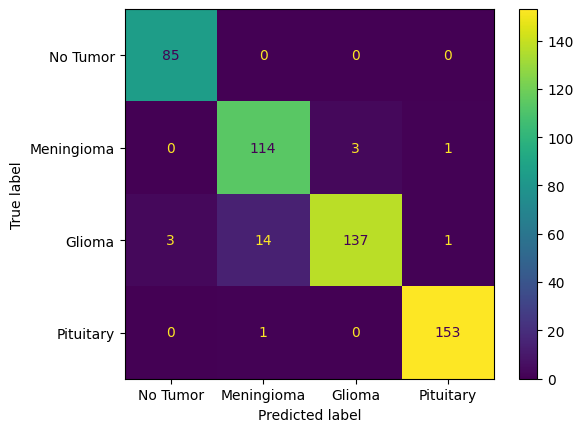

In [ ]:
cm = confusion_matrix(testLabel, predicted)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()
plt.show()

Grad-CAM

True: 1, Predicted: tensor([1])


'\n  fig, ax = plt.subplots(1,2,figsize=(10,5))\n\n  ax[0].imshow(testImage)\n\n  ax[1].imshow(heatmap)\n  ax[1].set_title("GradCAM Heatmap")\n  '

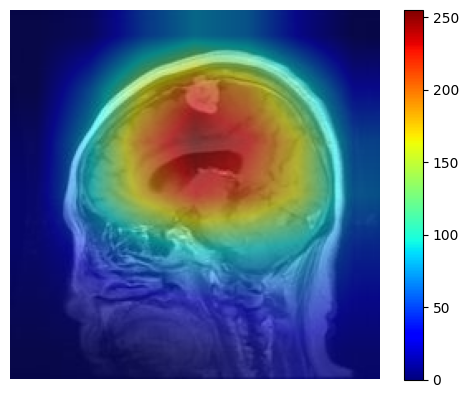

In [19]:
images, labels = next(iter(testLoader))

testImage = images[0]
label = labels[0]

outputs = model(testImage.unsqueeze(0))
_, predictedClass = torch.max(outputs,1)
targets = [ClassifierOutputTarget(predictedClass)]

layers = [model.layer4[-1]]
cam = GradCAM(model = model, target_layers = layers)
heatmap = cam(input_tensor = testImage.unsqueeze(0), targets = targets)

print(f'True: {label}, Predicted: {predictedClass}')

testImage = testImage.permute(1, 2, 0).cpu().numpy()
testImage = (testImage - testImage.min()) / (testImage.max() - testImage.min())
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
visualization = show_cam_on_image(
    testImage,
    heatmap[0],
    use_rgb=True
)

plt.imshow(visualization, cmap='jet')
plt.colorbar()
plt.axis('off')

"""
  fig, ax = plt.subplots(1,2,figsize=(10,5))

  ax[0].imshow(testImage)

  ax[1].imshow(heatmap)
  ax[1].set_title("GradCAM Heatmap")
  """

LLM

In [ ]:
modelName = "Qwen/Qwen2.5-0.5B-Instruct"

modelLLM = AutoModelForCausalLM.from_pretrained(
    modelName,
    torch_dtype="auto",
    device_map="auto"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(modelName)

if label.item() == 0:
  reportDictClass = classification_report(testLabel, predicted,labels = [0], target_names=classes, output_dict=False)
elif label.item() == 1:
  reportDictClass = classification_report(testLabel, predicted,labels = [1], target_names=classes,output_dict=False)
elif label.item() == 2:
  reportDictClass = classification_report(testLabel, predicted,labels = [2], target_names=classes,output_dict=False)
elif label.item() == 3:
  reportDictClass = classification_report(testLabel, predicted,labels = [3], target_names=classes,output_dict=False)

prompt = f"""
              The Prediction and True Labels are mapped 0 has no Tumor, 1 is a Meningioma, 2 is a Glioma, 3 is a Pituitary
              These labels are NOT to be interpreted as severity of tumour, if present

              Model Preformance: {reportDictClass}, use this as supporting information and only incorperate numerical values
              What the Model Predicted: {predictedClass}
              What the True Value: {label.item()}
              Values between 0.7 and 1 are considered high/good

              Be Consistant in reporting
              Do not relate the model preformance with with the model predicted or true value.
              Do not mention any terms that have not been provided
              Do not assume that if there are significant values in image2 there is a lesion
              Use the actual values in your explination

              Explain why the CNN may have made this prediction & where the tumour, if present, is within the brain using image1 and image2 and neuroanatomy terminology. Do not give general information about AI.

              Limit to 6 sentances
              """
messages = [
    {"role": "system", "content": "You are an board certified neuroradiologist reading an MRI."},
    {"type": "image", "image1": testImage},
    {"type": "image", "image2": heatmap},
    {"role": "user", "content": prompt},
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(modelLLM.device)

generated_ids = modelLLM.generate(
    **model_inputs,
    max_new_tokens=512
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(response)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 1, does not match size of target_names, 4
  warnings.warn(


The CNN likely predicted a high/strong tumor based on its accuracy scores for both classes (No Tumor vs Micro Avg) which were close to 1 (indicating good performance). Given the specific label 'micro avg' and considering the context provided, it seems the tumor was localized within the midbrain region. This could suggest a benign, low-grade glioma or meningioma, given the specificity thresholds mentioned. However, more detailed examination would be necessary to confirm the nature of the tumor.
